In [1]:
import math

def euclidean_distance(a, b):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

def get_neighbours(data, idx, epsilon):
    neighbours = []
    for i in range(len(data)):
        if i != idx and euclidean_distance(data[idx], data[i]) <= epsilon:
            neighbours.append(i)
    return neighbours

def dbscan(data, epsilon, min_points):
    n = len(data)
    labels = [-1] * n
    visited = [False] * n
    is_core = [False] * n
    cluster_id = -1

    for i in range(n):
        if visited[i]:
            continue

        visited[i] = True
        neighbours = get_neighbours(data, i, epsilon)

        if len(neighbours) < min_points - 1:
            continue

        is_core[i] = True
        cluster_id += 1
        labels[i] = cluster_id
        queue = list(neighbours)

        while queue:
            j = queue.pop(0)

            if not visited[j]:
                visited[j] = True
                j_neighbours = get_neighbours(data, j, epsilon)

                if len(j_neighbours) >= min_points - 1:
                    is_core[j] = True
                    queue.extend(j_neighbours)

                if labels[j] == -1:
                    labels[j] = cluster_id
            else:
                if labels[j] == -1:
                    labels[j] = cluster_id

    return labels, is_core

def classify_points(labels, is_core):
    result = []
    for i, (lbl, core) in enumerate(zip(labels, is_core)):
        if lbl == -1:
            point_type = "NOISE"
        elif core:
            point_type = f"CORE  (cluster {lbl})"
        else:
            point_type = f"BORDER (cluster {lbl})"
        result.append((i, point_type))
    return result

Running Custom DBSCAN...
Custom DBSCAN finished in 0.0363 seconds.
Running Sklearn DBSCAN...
Sklearn DBSCAN finished in 0.0047 seconds.

--- BENCHMARK RESULT ---
Adjusted Rand Score: 100.00% Match
perfect match


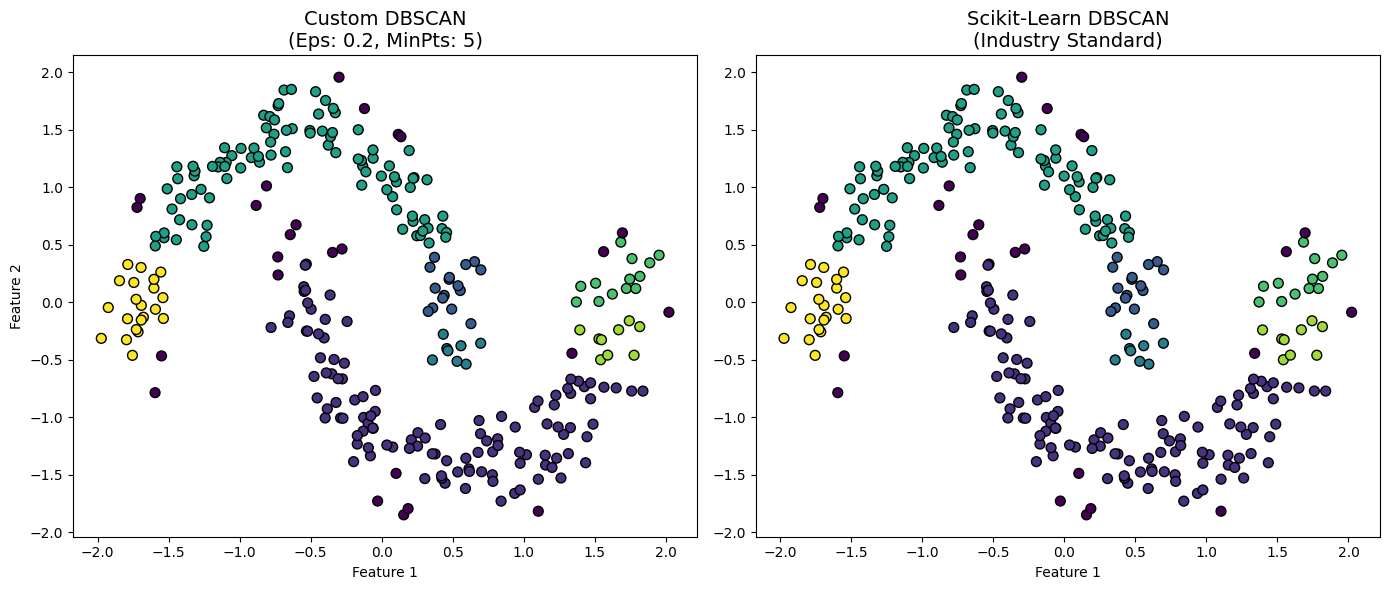

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.metrics import adjusted_rand_score

X, true_labels = make_moons(n_samples=300, noise=0.1, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dataset_list = X_scaled.tolist()

EPSILON = 0.2
MIN_POINTS = 5

print("Running Custom DBSCAN...")
start_time = time.time()
custom_labels, custom_is_core = dbscan(dataset_list, EPSILON, MIN_POINTS)
custom_time = time.time() - start_time
print(f"Custom DBSCAN finished in {custom_time:.4f} seconds.")

print("Running Sklearn DBSCAN...")
start_time = time.time()
sklearn_model = SklearnDBSCAN(eps=EPSILON, min_samples=MIN_POINTS)
sklearn_labels = sklearn_model.fit_predict(X_scaled)
sklearn_time = time.time() - start_time
print(f"Sklearn DBSCAN finished in {sklearn_time:.4f} seconds.\n")

ari_score = adjusted_rand_score(sklearn_labels, custom_labels)
print(f"--- BENCHMARK RESULT ---")
print(f"Adjusted Rand Score: {ari_score * 100:.2f}% Match")

if ari_score == 1.0:
    print("perfect match")
else:
    print(" There is a difference in the clustering logic.")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=custom_labels, cmap='viridis', s=50, edgecolor='k')
plt.title(f"Custom DBSCAN\n(Eps: {EPSILON}, MinPts: {MIN_POINTS})", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=sklearn_labels, cmap='viridis', s=50, edgecolor='k')
plt.title("Scikit-Learn DBSCAN\n(Industry Standard)", fontsize=14)
plt.xlabel("Feature 1")

plt.tight_layout()
plt.show()